
# RQ4 — Confidence Calibration Analysis

This notebook analyzes whether specification explicitness affects developers' ability to judge the correctness of LLM-generated code.

**RQ4.** Does specification explicitness affect confidence calibration in LLM-assisted development?

The notebook produces:

1. a participant-phase calibration dataset;
2. descriptive calibration tables by specification condition and phase;
3. publication-ready figures for ICSE-style reporting;
4. a mixed-effects model for overconfidence with participant random intercepts;
5. estimated marginal means and pairwise contrasts;
6. sensitivity analyses using prompt--specification alignment and prompt-type features.

**Participant controls.** LLM familiarity is merged from questionnaire Q3, and Python skill is merged from questionnaire Q5.

**Primary outcome.** Overconfidence is computed as predicted hidden-test performance minus observed hidden-test performance. Positive values mean participants overestimated correctness.


In [ ]:
# ============================================================
# 0. Setup
# ============================================================

from pathlib import Path
import warnings
import re

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import statsmodels.formula.api as smf
import statsmodels.api as sm
from scipy import stats
from statsmodels.stats.multitest import multipletests

try:
    import patsy
except ImportError:
    patsy = None


# ============================================================
# Project paths
# ============================================================

def find_project_paths(start_path=None):
    """
    Find the project root and its data directory by searching
    the current directory and its parent directories.
    """
    start_path = Path(start_path or Path.cwd()).resolve()

    for directory in [start_path, *start_path.parents]:
        for data_folder_name in ("data", "Data"):
            data_directory = directory / data_folder_name

            if data_directory.is_dir():
                return directory, data_directory

    # Fallback for uploaded notebook environments.
    upload_directory = Path("Data")

    if upload_directory.is_dir():
        return upload_directory, upload_directory

    raise FileNotFoundError(
        "Could not find a 'data' or 'Data' directory in "
        f"'{start_path}' or any of its parent directories."
    )


PROJECT_ROOT, DATA_DIR = find_project_paths()


def resolve_data_path(relative_path):
    """
    Resolve a path relative to the project's data directory.
    """
    relative_path = Path(relative_path)

    candidates = [
        DATA_DIR / relative_path,
        Path("Data") / relative_path,
        Path("Data") / relative_path.name,
        Path.cwd() / relative_path,
    ]

    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()

    attempted_paths = "\n".join(
        f"  - {candidate}" for candidate in candidates
    )

    raise FileNotFoundError(
        f"Could not find '{relative_path}'. Tried:\n"
        f"{attempted_paths}"
    )


# ============================================================
# Output directories
# ============================================================

OUT = Path("rq4_outputs")
FIG_DIR = OUT / "figures"
TAB_DIR = OUT / "tables"

for directory in [OUT, FIG_DIR, TAB_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


# ============================================================
# Input files
# ============================================================

PHASE1_PATH = resolve_data_path("dataset_phase1.csv")
PHASE2_PATH = resolve_data_path("dataset_phase2.csv")

QUESTIONNAIRE_PATH = resolve_data_path(
    Path("demographic") / "questionnair.csv"
)

PROMPT_SUMMARY_P1 = resolve_data_path(
    Path("prompt_data") / "Phase1_prompt_summary.csv"
)

PROMPT_SUMMARY_P2 = resolve_data_path(
    Path("prompt_data") / "Phase2_prompt_summary.csv"
)

PROMPT_TYPE_P1 = resolve_data_path(
    Path("prompt_data") / "Phase1_prompt_type.csv"
)

PROMPT_TYPE_P2 = resolve_data_path(
    Path("prompt_data") / "Phase2_prompt_type.csv"
)

ALIGN_SUMMARY_P1 = resolve_data_path(
    Path("prompt_data") / "Phase1_spec_alignment_summary.csv"
)

ALIGN_SUMMARY_P2 = resolve_data_path(
    Path("prompt_data") / "Phase2_spec_alignment_summary.csv"
)


# ============================================================
# Plot settings
# ============================================================

# ICSE-friendly colors used consistently across figures.
SPEC_ORDER = ["G1", "G2", "G3"]
PHASE_ORDER = ["Phase 1", "Phase 2"]

SPEC_COLORS = {
    "G1": "#b7e3ff",
    "G2": "#6fb6ff",
    "G3": "#5668cc",
}

PHASE_MARKERS = {
    "Phase 1": "o",
    "Phase 2": "s",
}

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


# ============================================================
# Confirm resolved paths
# ============================================================

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUT}")
print(f"Figure directory: {FIG_DIR}")
print(f"Table directory: {TAB_DIR}")

print(f"Phase I dataset: {PHASE1_PATH}")
print(f"Phase II dataset: {PHASE2_PATH}")
print(f"Questionnaire: {QUESTIONNAIRE_PATH}")
print(f"Prompt summary P1: {PROMPT_SUMMARY_P1}")
print(f"Prompt summary P2: {PROMPT_SUMMARY_P2}")
print(f"Prompt type P1: {PROMPT_TYPE_P1}")
print(f"Prompt type P2: {PROMPT_TYPE_P2}")
print(f"Alignment summary P1: {ALIGN_SUMMARY_P1}")
print(f"Alignment summary P2: {ALIGN_SUMMARY_P2}")


## 1. Load and harmonize phase datasets

The raw survey confidence items are categorical confidence bins. We map them to an ordinal score and to the midpoint of the corresponding pass-rate interval:

- 1 = 0--20% confidence → midpoint 10%;
- 2 = 21--40% confidence → midpoint 30%;
- 3 = 41--60% confidence → midpoint 50%;
- 4 = 61--80% confidence → midpoint 70%;
- 5 = 81--100% confidence → midpoint 90%.

The primary calibration metric is:

\[
\mathrm{Overconfidence}_{i,p}=\mathrm{PredictedPassPct}_{i,p}-\mathrm{ObservedPassPct}_{i,p}.
\]


Participant-level controls are merged from `questionnair.csv`: Q3 is used as the ordinal LLM-familiarity self-report, and Q5 is used as the ordinal Python-skill self-report.

In [3]:

# ============================================================
# 1. Helper functions
# ============================================================

def clean_confidence_to_ordinal(x):
    # Map numeric or textual confidence values to 1--5 ordinal categories.
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s == '':
        return np.nan
    # Numeric strings, including '3.0'.
    try:
        v = float(s)
        if 1 <= v <= 5:
            return int(round(v))
    except Exception:
        pass
    s_low = s.lower().replace('–', '-').replace('—', '-')
    if 'not confident' in s_low or '0-20' in s_low:
        return 1
    if 'slightly' in s_low or '21-40' in s_low:
        return 2
    if 'moderately' in s_low or '41-60' in s_low:
        return 3
    if 'very confident' in s_low or '61-80' in s_low or '61- 80' in s_low:
        return 4
    if 'extremely' in s_low or '81-100' in s_low:
        return 5
    return np.nan


def actual_pct_to_category(pct):
    # Map observed hidden-test pass percentage to the same 1--5 bins.
    if pd.isna(pct):
        return np.nan
    if pct <= 20:
        return 1
    if pct <= 40:
        return 2
    if pct <= 60:
        return 3
    if pct <= 80:
        return 4
    return 5


def standardize_id(df):
    # Return a copy with an id column, using anon_id where needed.
    df = df.copy()
    if 'id' not in df.columns and 'anon_id' in df.columns:
        df = df.rename(columns={'anon_id': 'id'})
    return df


def summarize_numeric(x):
    x = pd.Series(x).dropna()
    if len(x) == 0:
        return pd.Series({'n': 0, 'mean': np.nan, 'sd': np.nan, 'median': np.nan, 'iqr': np.nan})
    return pd.Series({
        'n': len(x),
        'mean': x.mean(),
        'sd': x.std(ddof=1),
        'median': x.median(),
        'iqr': x.quantile(.75) - x.quantile(.25),
    })


def mean_ci(x, alpha=.05):
    x = pd.Series(x).dropna()
    n = len(x)
    if n == 0:
        return (np.nan, np.nan, np.nan)
    m = x.mean()
    if n == 1:
        return (m, np.nan, np.nan)
    se = x.std(ddof=1) / np.sqrt(n)
    crit = stats.t.ppf(1-alpha/2, n-1)
    return (m, m - crit*se, m + crit*se)


def cohens_d_independent(a, b):
    # Hedges g for two independent groups.
    a = pd.Series(a).dropna().astype(float)
    b = pd.Series(b).dropna().astype(float)
    n1, n2 = len(a), len(b)
    if n1 < 2 or n2 < 2:
        return np.nan
    s1, s2 = a.std(ddof=1), b.std(ddof=1)
    sp = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    if sp == 0:
        return np.nan
    d = (a.mean() - b.mean()) / sp
    J = 1 - (3 / (4*(n1+n2)-9))
    return J * d




In [4]:

# ============================================================
# 2. Load phase data and compute calibration outcomes
# ============================================================

p1 = standardize_id(pd.read_csv(PHASE1_PATH))
p2 = standardize_id(pd.read_csv(PHASE2_PATH))

# Phase 1 already has specification and Task. Phase 2 derives them from version.
p1['specification'] = p1['specification'].astype(str).str.strip()
p1['Task'] = p1['Task'].astype(str).str.strip()
p2['specification'] = p2['version'].astype(str).str[:2]
p2['Task'] = p2['version'].astype(str).str[-1]

# Participant-level controls are merged from the questionnaire file.
# Q2 = LLM familiarity; Q4 = Python skill.
questionnaire = standardize_id(pd.read_csv(QUESTIONNAIRE_PATH))
questionnaire['llm_familiarity'] = pd.to_numeric(questionnaire['Q2'], errors='coerce')
questionnaire['python_skill'] = pd.to_numeric(questionnaire['Q4'], errors='coerce')
controls = questionnaire[['id', 'Q2', 'Q4', 'llm_familiarity', 'python_skill']].copy()

# Save an audit table so the analysis is transparent about how Q2/Q4 were encoded.
controls.to_csv(TAB_DIR / 'rq4_questionnaire_controls_q2_q4.csv', index=False)
print('Questionnaire controls merged:', controls[['id','llm_familiarity','python_skill']].notna().sum().to_dict())

# Build phase-specific calibration datasets.
p1_cal = p1[['id', 'specification', 'Task', 'num_hidden_test_passed_phase1', 'num_hidden_test_failed_phase1', 'before_p_8']].copy()
p1_cal = p1_cal.rename(columns={
    'num_hidden_test_passed_phase1': 'hidden_passed',
    'num_hidden_test_failed_phase1': 'hidden_failed',
    'before_p_8': 'predicted_raw',
})
p1_cal['phase'] = 'Phase 1'

p2_cal = p2[['id', 'specification', 'Task', 'num_hidden_test_passed_phase2', 'num_hidden_test_failed_phase2', 'after_cr_6']].copy()
p2_cal = p2_cal.rename(columns={
    'num_hidden_test_passed_phase2': 'hidden_passed',
    'num_hidden_test_failed_phase2': 'hidden_failed',
    'after_cr_6': 'predicted_raw',
})
p2_cal['phase'] = 'Phase 2'

cal = pd.concat([p1_cal, p2_cal], ignore_index=True)
cal = cal.merge(controls, on='id', how='left')

cal['predicted_categ'] = cal['predicted_raw'].apply(clean_confidence_to_ordinal)
cal['predicted_midpoint_pct'] = cal['predicted_categ'].map({1:10, 2:30, 3:50, 4:70, 5:90})
cal['total_hidden_tests'] = cal['hidden_passed'] + cal['hidden_failed']
cal['actual_pct'] = 100 * cal['hidden_passed'] / cal['total_hidden_tests']
cal['actual_categ'] = cal['actual_pct'].apply(actual_pct_to_category)

# Primary and secondary calibration outcomes.
cal['overconfidence_pp'] = cal['predicted_midpoint_pct'] - cal['actual_pct']
cal['abs_calibration_error_pp'] = cal['overconfidence_pp'].abs()
cal['ordinal_calibration_gap'] = cal['predicted_categ'] - cal['actual_categ']
cal['well_calibrated_bin'] = (cal['ordinal_calibration_gap'] == 0).astype(float)
cal['overconfident_bin'] = (cal['ordinal_calibration_gap'] > 0).astype(float)
cal['underconfident_bin'] = (cal['ordinal_calibration_gap'] < 0).astype(float)

# Order factors for stable plotting/reporting.
cal['specification'] = pd.Categorical(cal['specification'], categories=SPEC_ORDER, ordered=True)
cal['phase'] = pd.Categorical(cal['phase'], categories=PHASE_ORDER, ordered=True)

# Drop rows without the calibration response.
cal = cal.dropna(subset=['predicted_categ', 'actual_pct']).copy()

cal.to_csv(OUT / 'rq4_calibration_long.csv', index=False)
print(cal.shape)
cal.head()


Questionnaire controls merged: {'id': 65, 'llm_familiarity': 69, 'python_skill': 69}
(140, 22)


,id,specification,Task,hidden_passed,hidden_failed,predicted_raw,phase,Q2,Q4,llm_familiarity,python_skill,predicted_categ,predicted_midpoint_pct,total_hidden_tests,actual_pct,actual_categ,overconfidence_pp,abs_calibration_error_pp,ordinal_calibration_gap,well_calibrated_bin,overconfident_bin,underconfident_bin
0,S0001,G1,A,10,23,1.0,Phase 1,3.0,3.0,3.0,3.0,1.0,10.0,33,30.303030,2,-20.303030,20.303030,-1.0,0.0,0.0,1.0
1,S0002,G1,A,12,21,4.0,Phase 1,NaN,NaN,NaN,NaN,4.0,70.0,33,36.363636,2,33.636364,33.636364,2.0,0.0,1.0,0.0
2,S0003,G1,A,10,23,4.0,Phase 1,5.0,2.0,5.0,2.0,4.0,70.0,33,30.303030,2,39.696970,39.696970,2.0,0.0,1.0,0.0
3,S0004,G1,A,5,28,3.0,Phase 1,1.0,3.0,1.0,3.0,3.0,50.0,33,15.151515,1,34.848485,34.848485,2.0,0.0,1.0,0.0
4,S0005,G1,A,13,20,1.0,Phase 1,3.0,2.0,3.0,2.0,1.0,10.0,33,39.393939,2,-29.393939,29.393939,-1.0,0.0,0.0,1.0



## 2. Add prompt-effort, prompt-type, and prompt--specification alignment features

Prompt-effort features are available for all groups. Prompt--specification alignment is defined only for G2/G3 because G1 participants did not receive an explicit specification artifact.


In [5]:

# ============================================================
# 3. Merge prompt summaries and alignment features
# ============================================================

def load_prompt_summary(path, phase_label):
    df = pd.read_csv(path).copy()
    df['phase'] = phase_label
    return df

prompt_summary = pd.concat([
    load_prompt_summary(PROMPT_SUMMARY_P1, 'Phase 1'),
    load_prompt_summary(PROMPT_SUMMARY_P2, 'Phase 2'),
], ignore_index=True)

# Prefix prompt-effort columns to avoid ambiguity.
prompt_summary = prompt_summary.rename(columns={
    'total_prompt_count': 'prompt_count',
    'total_prompt_len': 'prompt_total_len',
    'average_prompt_len': 'prompt_avg_len',
})

# Prompt-type shares are derived from prompt-level coded data as a robustness/sensitivity feature.
def load_prompt_type(path, phase_label):
    df = pd.read_csv(path).copy()
    df['phase'] = phase_label
    return df

prompt_type = pd.concat([
    load_prompt_type(PROMPT_TYPE_P1, 'Phase 1'),
    load_prompt_type(PROMPT_TYPE_P2, 'Phase 2'),
], ignore_index=True)

prompt_type_counts = (
    prompt_type
    .groupby(['id', 'phase', 'prompt_category'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Normalize prompt category names into compact variable names.
rename_prompt_cols = {}
for c in prompt_type_counts.columns:
    if c not in ['id', 'phase']:
        safe = str(c).lower().replace(' ', '_').replace('-', '_').replace('/', '_').replace('only', '').strip('_')
        safe = ''.join(ch for ch in safe if ch.isalnum() or ch == '_')
        rename_prompt_cols[c] = 'ptype_' + safe
prompt_type_counts = prompt_type_counts.rename(columns=rename_prompt_cols)
# Multiple raw labels can normalize to the same compact name; combine them.
prompt_type_counts = prompt_type_counts.T.groupby(level=0).sum().T

ptype_cols = [c for c in prompt_type_counts.columns if c.startswith('ptype_')]
prompt_type_counts['ptype_total_coded_prompts'] = prompt_type_counts[ptype_cols].sum(axis=1)
for c in ptype_cols:
    prompt_type_counts[c + '_share'] = np.where(
        prompt_type_counts['ptype_total_coded_prompts'] > 0,
        prompt_type_counts[c] / prompt_type_counts['ptype_total_coded_prompts'],
        np.nan,
    )

# Alignment summaries.
def load_align(path, phase_label):
    df = pd.read_csv(path).copy()
    df['phase'] = phase_label
    return df

align = pd.concat([
    load_align(ALIGN_SUMMARY_P1, 'Phase 1'),
    load_align(ALIGN_SUMMARY_P2, 'Phase 2'),
], ignore_index=True)

# Merge all features into the RQ4 calibration dataset.
cal2 = cal.merge(prompt_summary, on=['id', 'phase'], how='left')
cal2 = cal2.merge(prompt_type_counts, on=['id', 'phase'], how='left')
cal2 = cal2.merge(align, on=['id', 'phase'], how='left', suffixes=('', '_align'))

cal2.to_csv(OUT / 'rq4_calibration_with_prompt_features.csv', index=False)
print(cal2.shape)
cal2.head()


(140, 1360)


,id,specification,Task,hidden_passed,hidden_failed,predicted_raw,phase,Q2,Q4,llm_familiarity,python_skill,predicted_categ,predicted_midpoint_pct,total_hidden_tests,actual_pct,actual_categ,overconfidence_pp,abs_calibration_error_pp,ordinal_calibration_gap,well_calibrated_bin,overconfident_bin,underconfident_bin,prompt_count,prompt_total_len,prompt_avg_len,clarification_count,debugging_count,code_generation_count,test_generation_count,ptype_category_clarification_reason_developer_asks_for_an_explanation_of_the_files_content_and_to_understand_the_requirements_which_is_a_request_for_clarification,ptype_category_clarification_reason_developer_asks_how_the_system_should_prioritize_between_multiple_feasible_allocation_scenarios_seeking_clarification_on_tiebreaking_behavior,ptype_category_clarification_reason_developer_asks_the_model_to_assess_possible_causes_of_a_failure_invariant_violation_missing_constraint_tiebreaking_parsing_assumption_and_seeks_clarification_on_which_is_most_likely,ptype_category_clarification_reason_developer_is_asking_to_clarify_the_scheduling_rules_and_specifications_from_tests_and_description_before_coding_the_suggest_slots_function,ptype_category_clarification_reason_the_developer_asks_a_question_about_handling_the_notimplementederror_placeholder_after_implementing_the_function_seeking_clarification_rather_than_code_or_debugging,ptype_category_clarification_reason_the_developer_asks_a_question_about_whether_they_should_validate_request_structure_seeking_clarification_rather_than_code_debugging_or_tests,ptype_category_clarification_reason_the_developer_asks_a_question_to_clarify_whether_a_change_impacts_input_validation_or_error_handling,ptype_category_clarification_reason_the_developer_asks_a_question_to_clarify_whether_a_specific_value_1500_is_permitted_indicating_a_need_for_information_rather_than_code_or_debugging,ptype_category_clarification_reason_the_developer_asks_a_question_to_clarify_whether_an_allocation_that_exactly_matches_capacities_is_considered_invalid,ptype_category_clarification_reason_the_developer_asks_a_question_to_understand_any_special_constraints_or_rules_seeking_clarification,ptype_category_clarification_reason_the_developer_asks_a_question_to_understand_any_special_constraints_or_rules_which_is_a_request_for_clarification,ptype_category_clarification_reason_the_developer_asks_a_question_to_understand_the_systems_objective_seeking_clarification_rather_than_code_debugging_or_test_generation,ptype_category_clarification_reason_the_developer_asks_a_vague_question_about_expected_outputs_seeking_clarification_rather_than_code_debugging_or_test_generation,ptype_category_clarification_reason_the_developer_asks_a_vague_question_about_the_systems_goal_seeking_clarification_rather_than_code_debugging_or_tests,ptype_category_clarification_reason_the_developer_asks_for_a_brief_description_of_the_systems_objective_which_is_a_request_for_clarification_rather_than_code_or_testing,ptype_category_clarification_reason_the_developer_asks_for_a_description_of_the_function_to_be_tested_seeking_clarification_about_its_structure_before_proceeding,ptype_category_clarification_reason_the_developer_asks_for_a_description_of_the_functions_return_value_seeking_clarification_rather_than_code_or_tests,ptype_category_clarification_reason_the_developer_asks_for_a_detailed_summary_of_how_to_implement_the_new_fridayafter3pm_exclusion_seeking_explanation_rather_than_code_tests_or_debugging,ptype_category_clarification_reason_the_developer_asks_for_a_list_of_at_least_three_invariants_that_should_always_hold_seeking_clarification_rather_than_code_or_debugging,ptype_category_clarification_reason_the_developer_asks_for_a_list_of_constraints_seeking_clarification_of_requirements_rather_than_code_debugging_or_test_generation,ptype_category_clarification_reason_the_developer_asks_for_a_short_explanation_of_a_documentation_file_about_running_pytest_which_is_a_request_for_clarification_rather_than_code_generation_debugging_or_


## 3. Data completeness checks

These checks help document how many participant-phase observations enter each analysis.


In [6]:

# ============================================================
# 4. Completeness checks
# ============================================================

completeness = (
    cal2
    .groupby(['phase', 'specification'], observed=False)
    .agg(
        n=('id', 'count'),
        n_with_prompt_summary=('prompt_count', lambda x: x.notna().sum()),
        n_with_alignment=('alignment_score', lambda x: x.notna().sum()),
        mean_actual_pct=('actual_pct', 'mean'),
        mean_predicted_pct=('predicted_midpoint_pct', 'mean'),
        mean_overconfidence_pp=('overconfidence_pp', 'mean'),
    )
    .reset_index()
)
completeness.to_csv(TAB_DIR / 'rq4_completeness_by_phase_spec.csv', index=False)
completeness


,phase,specification,n,n_with_prompt_summary,n_with_alignment,mean_actual_pct,mean_predicted_pct,mean_overconfidence_pp
0,Phase 1,G1,24,23,0,34.722222,57.500000,22.777778
1,Phase 1,G2,22,22,22,39.807163,45.454545,5.647383
2,Phase 1,G3,24,23,23,65.530303,43.333333,-22.196970
3,Phase 2,G1,24,24,0,39.772727,62.500000,22.727273
4,Phase 2,G2,23,23,23,73.517787,56.086957,-17.430830
5,Phase 2,G3,23,23,23,74.308300,56.086957,-18.221344



## 4. Descriptive calibration results

The table below reports predicted performance, actual performance, overconfidence, and absolute calibration error by phase and specification condition.


In [7]:

# ============================================================
# 5. Descriptive table by phase and specification condition
# ============================================================

rows = []
for (phase, spec), g in cal2.groupby(['phase', 'specification'], observed=False):
    m_ov, lo_ov, hi_ov = mean_ci(g['overconfidence_pp'])
    m_abs, lo_abs, hi_abs = mean_ci(g['abs_calibration_error_pp'])
    rows.append({
        'phase': phase,
        'specification': spec,
        'n': len(g),
        'predicted_pct_mean': g['predicted_midpoint_pct'].mean(),
        'actual_pct_mean': g['actual_pct'].mean(),
        'overconfidence_pp_mean': m_ov,
        'overconfidence_pp_ci_low': lo_ov,
        'overconfidence_pp_ci_high': hi_ov,
        'abs_error_pp_mean': m_abs,
        'abs_error_pp_ci_low': lo_abs,
        'abs_error_pp_ci_high': hi_abs,
        'overconfident_pct': 100*g['overconfident_bin'].mean(),
        'well_calibrated_pct': 100*g['well_calibrated_bin'].mean(),
        'underconfident_pct': 100*g['underconfident_bin'].mean(),
    })

desc = pd.DataFrame(rows)
desc.to_csv(TAB_DIR / 'rq4_descriptive_calibration_by_phase_spec.csv', index=False)
desc.round(2)


,phase,specification,n,predicted_pct_mean,actual_pct_mean,overconfidence_pp_mean,overconfidence_pp_ci_low,overconfidence_pp_ci_high,abs_error_pp_mean,abs_error_pp_ci_low,abs_error_pp_ci_high,overconfident_pct,well_calibrated_pct,underconfident_pct
0,Phase 1,G1,24,57.50,34.72,22.78,13.24,32.32,29.37,24.17,34.57,83.33,4.17,12.50
1,Phase 1,G2,22,45.45,39.81,5.65,-3.18,14.48,16.94,11.90,21.98,45.45,36.36,18.18
2,Phase 1,G3,24,43.33,65.53,-22.20,-37.19,-7.20,31.57,20.12,43.01,12.50,29.17,58.33
3,Phase 2,G1,24,62.50,39.77,22.73,13.51,31.95,26.11,18.75,33.47,79.17,12.50,8.33
4,Phase 2,G2,23,56.09,73.52,-17.43,-33.00,-1.86,31.98,21.88,42.07,26.09,17.39,56.52
5,Phase 2,G3,23,56.09,74.31,-18.22,-31.23,-5.21,28.39,19.64,37.15,13.04,30.43,56.52


In [8]:

# Compact LaTeX table for paper draft.
latex_desc = desc.copy()
for c in latex_desc.select_dtypes(include=[float]).columns:
    latex_desc[c] = latex_desc[c].map(lambda x: f'{x:.2f}' if pd.notna(x) else '--')
latex_table = latex_desc[[
    'phase', 'specification', 'n', 'predicted_pct_mean', 'actual_pct_mean',
    'overconfidence_pp_mean', 'abs_error_pp_mean', 'overconfident_pct'
]].to_latex(index=False, escape=False)
with open(TAB_DIR / 'rq4_descriptive_calibration_table.tex', 'w') as f:
    f.write(latex_table)
print(latex_table)


\begin{tabular}{llrlllll}
\toprule
phase & specification & n & predicted_pct_mean & actual_pct_mean & overconfidence_pp_mean & abs_error_pp_mean & overconfident_pct \\
\midrule
Phase 1 & G1 & 24 & 57.50 & 34.72 & 22.78 & 29.37 & 83.33 \\
Phase 1 & G2 & 22 & 45.45 & 39.81 & 5.65 & 16.94 & 45.45 \\
Phase 1 & G3 & 24 & 43.33 & 65.53 & -22.20 & 31.57 & 12.50 \\
Phase 2 & G1 & 24 & 62.50 & 39.77 & 22.73 & 26.11 & 79.17 \\
Phase 2 & G2 & 23 & 56.09 & 73.52 & -17.43 & 31.98 & 26.09 \\
Phase 2 & G3 & 23 & 56.09 & 74.31 & -18.22 & 28.39 & 13.04 \\
\bottomrule
\end{tabular}




## 5. Visualization A — Predicted versus actual performance

Points above the diagonal indicate overconfidence. Points below the diagonal indicate underconfidence.


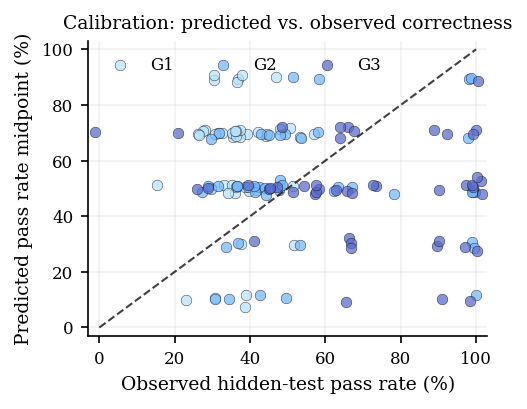

In [9]:

# ============================================================
# Figure 1: Predicted vs actual hidden-test performance
# ============================================================

fig, ax = plt.subplots(figsize=(3.45, 2.8))

# Small deterministic jitter to reduce overlap.
rng = np.random.default_rng(42)
plot_df = cal2.copy()
plot_df['pred_jitter'] = plot_df['predicted_midpoint_pct'] + rng.normal(0, 1.4, len(plot_df))
plot_df['actual_jitter'] = plot_df['actual_pct'] + rng.normal(0, 1.0, len(plot_df))

for spec in SPEC_ORDER:
    g = plot_df[plot_df['specification'].astype(str) == spec]
    ax.scatter(
        g['actual_jitter'], g['pred_jitter'],
        s=26, alpha=.72, edgecolor='black', linewidth=.25,
        color=SPEC_COLORS[spec], label=spec,
    )

ax.plot([0, 100], [0, 100], linestyle='--', linewidth=1, color='black', alpha=.75)
ax.set_xlim(-3, 103)
ax.set_ylim(-3, 103)
ax.set_xlabel('Observed hidden-test pass rate (%)')
ax.set_ylabel('Predicted pass rate midpoint (%)')
ax.set_title('Calibration: predicted vs. observed correctness')
ax.legend(frameon=False, ncol=3, loc='upper left')
ax.grid(axis='both', alpha=.18)

fig.tight_layout()
fig.savefig(FIG_DIR / 'rq4_predicted_vs_actual.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'rq4_predicted_vs_actual.png', bbox_inches='tight')
plt.show()



## 6. Visualization B — Overconfidence by specification and phase

This figure directly supports the RQ4 narrative. The y-axis is percentage-point overconfidence; lower values mean better calibration when the baseline pattern is overconfidence.


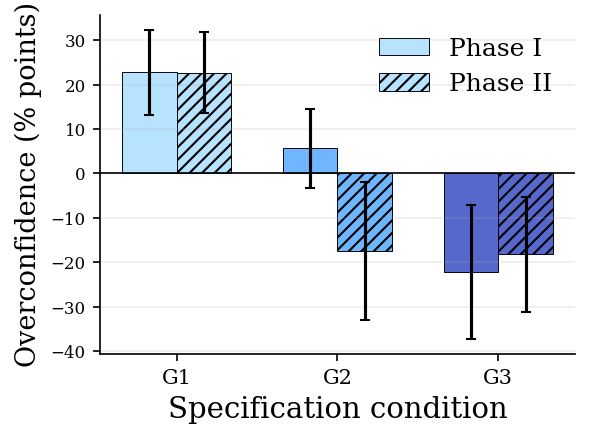

In [10]:

# ============================================================
# Figure 2: Overconfidence by condition and phase
# ============================================================

fig, ax = plt.subplots(figsize=(4, 3))

x = np.arange(len(SPEC_ORDER))
bar_width = 0.34

phase_offsets = {
    'Phase 1': -bar_width / 2,
    'Phase 2':  bar_width / 2
}

hatches = {
    'Phase 1': '',
    'Phase 2': '////'
}

# Display labels for the legend
phase_labels = {
    'Phase 1': 'Phase I',
    'Phase 2': 'Phase II'
}

for phase in PHASE_ORDER:
    vals, err_low, err_high = [], [], []

    for spec in SPEC_ORDER:
        g = cal2[
            (cal2['phase'].astype(str) == phase)
            & (cal2['specification'].astype(str) == spec)
        ]

        m, lo, hi = mean_ci(g['overconfidence_pp'])
        vals.append(m)
        err_low.append(m - lo if pd.notna(lo) else 0)
        err_high.append(hi - m if pd.notna(hi) else 0)

    positions = x + phase_offsets[phase]

    ax.bar(
        positions,
        vals,
        bar_width,
        color=[SPEC_COLORS[s] for s in SPEC_ORDER],
        edgecolor='black',
        linewidth=.45,
        hatch=hatches[phase],
        yerr=[err_low, err_high],
        capsize=2.5,
        label=phase_labels[phase],
    )

ax.axhline(0, color='black', linewidth=.8)
ax.set_xticks(x)
ax.set_xticklabels(SPEC_ORDER, fontsize=10)
ax.set_xlabel('Specification condition', fontsize=14)
ax.set_ylabel('Overconfidence (% points)', fontsize=13)
ax.grid(axis='y', alpha=.22)
ax.legend(frameon=False, title=None, fontsize=12)

fig.tight_layout()
fig.savefig(
    FIG_DIR / 'rq4_overconfidence_by_condition_phase.pdf',
    bbox_inches='tight'
)
fig.savefig(
    FIG_DIR / 'rq4_overconfidence_by_condition_phase.png',
    bbox_inches='tight'
)
plt.show()



## 7. Visualization C — Phase-to-phase change within participants

This plot shows whether calibration shifts from Phase I to Phase II for each condition.


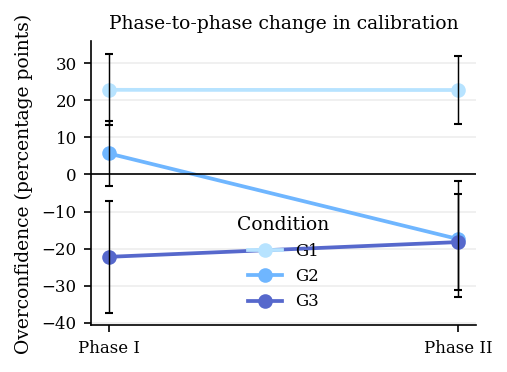

In [11]:

# ============================================================
# Figure 3: Phase-to-phase calibration change by specification
# ============================================================

fig, ax = plt.subplots(figsize=(3.45, 2.55))

summary = (
    cal2.groupby(['specification', 'phase'], observed=False)['overconfidence_pp']
    .apply(lambda s: pd.Series({'mean': s.mean(), 'sem': s.sem()}))
    .reset_index()
)
summary = summary.pivot_table(index='specification', columns='phase', values='overconfidence_pp') if False else None

for spec in SPEC_ORDER:
    vals = []
    lows = []
    highs = []
    for phase in PHASE_ORDER:
        g = cal2[(cal2['specification'].astype(str) == spec) & (cal2['phase'].astype(str) == phase)]
        m, lo, hi = mean_ci(g['overconfidence_pp'])
        vals.append(m); lows.append(lo); highs.append(hi)
    xs = [0, 1]
    ax.plot(xs, vals, marker='o', linewidth=1.8, color=SPEC_COLORS[spec], label=spec)
    ax.errorbar(xs, vals, yerr=[np.array(vals)-np.array(lows), np.array(highs)-np.array(vals)], fmt='none',
                ecolor='black', elinewidth=.7, capsize=2)

ax.axhline(0, color='black', linewidth=.8)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Phase I', 'Phase II'])
ax.set_ylabel('Overconfidence (percentage points)')
ax.set_title('Phase-to-phase change in calibration')
ax.grid(axis='y', alpha=.22)
ax.legend(frameon=False, title='Condition')

fig.tight_layout()
fig.savefig(FIG_DIR / 'rq4_phase_change_overconfidence.pdf', bbox_inches='tight')
fig.savefig(FIG_DIR / 'rq4_phase_change_overconfidence.png', bbox_inches='tight')
plt.show()



## 8. Mixed-effects model for overconfidence

The primary model estimates overconfidence as a function of specification condition, phase, and their interaction, controlling for task, Python skill, and LLM familiarity. Participant is included as a random intercept because each participant contributes observations from both phases.

Model:

\[
\mathrm{Overconfidence} \sim \mathrm{Specification} \times \mathrm{Phase} + \mathrm{Task} + \mathrm{PythonSkill} + \mathrm{LLMFamiliarity} + (1\mid \mathrm{Participant}).
\]


In [12]:

# ============================================================
# 8. Primary mixed-effects model
# ============================================================

model_df = cal2.dropna(subset=['overconfidence_pp', 'specification', 'phase', 'Task', 'python_skill', 'llm_familiarity']).copy()
model_df['specification'] = pd.Categorical(model_df['specification'], categories=SPEC_ORDER, ordered=False)
model_df['phase'] = pd.Categorical(model_df['phase'], categories=PHASE_ORDER, ordered=False)
model_df['Task'] = pd.Categorical(model_df['Task'])

formula = 'overconfidence_pp ~ C(specification, Treatment(reference="G1")) * C(phase, Treatment(reference="Phase 1")) + C(Task) + python_skill + llm_familiarity'

mixed_fit = None
model_used = None
try:
    md_model = smf.mixedlm(formula, data=model_df, groups=model_df['id'])
    mixed_fit = md_model.fit(reml=False, method='lbfgs', maxiter=1000)
    model_used = 'MixedLM random-intercept model'
    print(mixed_fit.summary())
except Exception as e:
    print('MixedLM failed; falling back to OLS with participant-clustered standard errors.')
    print('Reason:', repr(e))
    mixed_fit = smf.ols(formula, data=model_df).fit(cov_type='cluster', cov_kwds={'groups': model_df['id']})
    model_used = 'OLS with participant-clustered SEs'
    print(mixed_fit.summary())

# Save coefficient table.
coef = pd.DataFrame({
    'term': mixed_fit.params.index,
    'estimate': mixed_fit.params.values,
    'std_error': mixed_fit.bse.values,
    'p_value': mixed_fit.pvalues.values,
})
try:
    ci = mixed_fit.conf_int()
    coef['ci_low'] = ci.iloc[:,0].values
    coef['ci_high'] = ci.iloc[:,1].values
except Exception:
    coef['ci_low'] = np.nan
    coef['ci_high'] = np.nan

# Adjust p-values within the RQ4 model family, excluding intercept and variance terms.
mask = ~coef['term'].str.contains('Intercept|Group Var', regex=True)
coef.loc[mask, 'p_adj_fdr'] = multipletests(coef.loc[mask, 'p_value'], method='fdr_bh')[1]
coef.to_csv(TAB_DIR / 'rq4_mixed_model_coefficients.csv', index=False)
coef.round(4)


                                                       Mixed Linear Model Regression Results
Model:                                        MixedLM                             Dependent Variable:                             overconfidence_pp
No. Observations:                             126                                 Method:                                         ML               
No. Groups:                                   65                                  Scale:                                          374.0496         
Min. group size:                              1                                   Log-Likelihood:                                 -579.4639        
Max. group size:                              2                                   Converged:                                      Yes              
Mean group size:                              1.9                                                                                                  
-------------------

,term,estimate,std_error,p_value,ci_low,ci_high,p_adj_fdr
0,Intercept,1.1857,13.8012,0.9315,-25.8642,28.2357,NaN
1,"C(specification, Treatment(reference=""G1""))[T.G2]",-13.1966,7.9265,0.0959,-28.7323,2.3391,0.1535
2,"C(specification, Treatment(reference=""G1""))[T.G3]",-45.3337,7.9270,0.0000,-60.8704,-29.7970,0.0000
3,"C(phase, Treatment(reference=""Phase 1""))[T.Pha...",3.3030,6.1160,0.5892,-8.6840,15.2901,0.6733
4,C(Task)[T.B],-13.3385,5.3142,0.0121,-23.7543,-2.9228,0.0322
5,"C(specification, Treatment(reference=""G1""))[T....",-24.7519,8.5669,0.0039,-41.5428,-7.9611,0.0154
6,"C(specification, Treatment(reference=""G1""))[T....",0.0144,8.5220,0.9987,-16.6883,16.7171,0.9987
7,python_skill,5.6410,2.9168,0.0531,-0.0759,11.3579,0.1062
8,llm_familiarity,2.5638,3.0140,0.3950,-3.3436,8.4713,0.5266
9,Group Var,0.6880,0.3234,0.0334,0.0541,1.3219,NaN



## 9. Estimated marginal means and pairwise contrasts

Estimated marginal means are reported for each specification × phase cell. Pairwise contrasts compare specification conditions within each phase and phase changes within each specification.


In [13]:

# ============================================================
# 9. Estimated marginal means and contrasts
# ============================================================

# EMMs from model predictions at mean covariates and reference/majority task.
mean_python = model_df['python_skill'].mean()
mean_llm = model_df['llm_familiarity'].mean()
ref_task = model_df['Task'].mode().iloc[0]

grid = pd.DataFrame([
    {'specification': spec, 'phase': phase, 'Task': ref_task, 'python_skill': mean_python, 'llm_familiarity': mean_llm}
    for phase in PHASE_ORDER for spec in SPEC_ORDER
])
grid['specification'] = pd.Categorical(grid['specification'], categories=SPEC_ORDER, ordered=False)
grid['phase'] = pd.Categorical(grid['phase'], categories=PHASE_ORDER, ordered=False)
grid['Task'] = pd.Categorical(grid['Task'], categories=model_df['Task'].cat.categories)

# Prediction for MixedLM and OLS both works through predict; CI is approximated from fixed-effect covariance.
grid['emm_overconfidence_pp'] = mixed_fit.predict(grid)

# Approximate fixed-effect prediction SE using design matrix if patsy is available.
if patsy is not None:
    X_grid = patsy.dmatrix(formula.split('~', 1)[1], grid, return_type='dataframe')
    X_grid = X_grid.reindex(columns=mixed_fit.fe_params.index if hasattr(mixed_fit, 'fe_params') else mixed_fit.params.index, fill_value=0)
    cov = mixed_fit.cov_params()
    # Keep only fixed-effect covariance columns.
    cov = cov.loc[X_grid.columns, X_grid.columns]
    pred_var = np.diag(X_grid.values @ cov.values @ X_grid.values.T)
    grid['se'] = np.sqrt(np.maximum(pred_var, 0))
    grid['ci_low'] = grid['emm_overconfidence_pp'] - 1.96 * grid['se']
    grid['ci_high'] = grid['emm_overconfidence_pp'] + 1.96 * grid['se']
else:
    grid['se'] = np.nan
    grid['ci_low'] = np.nan
    grid['ci_high'] = np.nan

emm = grid[['phase', 'specification', 'emm_overconfidence_pp', 'se', 'ci_low', 'ci_high']].copy()
emm.to_csv(TAB_DIR / 'rq4_estimated_marginal_means.csv', index=False)
emm.round(3)


,phase,specification,emm_overconfidence_pp,se,ci_low,ci_high
0,Phase 1,G1,26.036,6.395,13.503,38.569
1,Phase 1,G2,12.840,6.010,1.059,24.620
2,Phase 1,G3,-19.298,5.922,-30.905,-7.690
3,Phase 2,G1,29.339,6.395,16.806,41.872
4,Phase 2,G2,-8.609,5.953,-20.277,3.058
5,Phase 2,G3,-15.980,5.991,-27.723,-4.237


In [14]:

# Pairwise contrasts based on observed data with Welch tests for spec comparisons
# and paired tests for phase changes. These complement model-based EMMs and are easy to audit.
contrast_rows = []

# Specification contrasts within each phase.
for phase in PHASE_ORDER:
    ph = cal2[cal2['phase'].astype(str) == phase]
    for a, b in [('G2','G1'), ('G3','G1'), ('G3','G2')]:
        ga = ph[ph['specification'].astype(str) == a]['overconfidence_pp']
        gb = ph[ph['specification'].astype(str) == b]['overconfidence_pp']
        t, p = stats.ttest_ind(ga.dropna(), gb.dropna(), equal_var=False)
        contrast_rows.append({
            'family': 'condition_within_phase',
            'phase': phase,
            'contrast': f'{a} - {b}',
            'estimate_diff_pp': ga.mean() - gb.mean(),
            'test': 'Welch t-test',
            'statistic': t,
            'p_value': p,
            'hedges_g': cohens_d_independent(ga, gb),
        })

# Phase contrasts within each specification, paired by participant.
for spec in SPEC_ORDER:
    wide = cal2[cal2['specification'].astype(str) == spec].pivot_table(
        index='id', columns='phase', values='overconfidence_pp', aggfunc='mean'
    ).dropna(subset=PHASE_ORDER)
    if len(wide) > 1:
        diff = wide['Phase 2'] - wide['Phase 1']
        t, p = stats.ttest_1samp(diff, 0)
        contrast_rows.append({
            'family': 'phase_within_condition',
            'phase': 'Phase 2 - Phase 1',
            'contrast': f'{spec}: Phase 2 - Phase 1',
            'estimate_diff_pp': diff.mean(),
            'test': 'paired t-test',
            'statistic': t,
            'p_value': p,
            'hedges_g': diff.mean() / diff.std(ddof=1) if diff.std(ddof=1) != 0 else np.nan,
        })

contrasts = pd.DataFrame(contrast_rows)
contrasts['p_adj_fdr'] = multipletests(contrasts['p_value'].fillna(1), method='fdr_bh')[1]
contrasts.to_csv(TAB_DIR / 'rq4_pairwise_contrasts.csv', index=False)
contrasts.round(4)


,family,phase,contrast,estimate_diff_pp,test,statistic,p_value,hedges_g,p_adj_fdr
0,condition_within_phase,Phase 1,G2 - G1,-17.1304,Welch t-test,-2.7330,0.0090,-0.7884,0.0135
1,condition_within_phase,Phase 1,G3 - G1,-44.9747,Welch t-test,-5.2357,0.0000,-1.4866,0.0000
2,condition_within_phase,Phase 1,G3 - G2,-27.8444,Welch t-test,-3.3151,0.0021,-0.9397,0.0047
3,condition_within_phase,Phase 2,G2 - G1,-40.1581,Welch t-test,-4.6000,0.0001,-1.3331,0.0002
4,condition_within_phase,Phase 2,G3 - G1,-40.9486,Welch t-test,-5.3209,0.0000,-1.5369,0.0000
5,condition_within_phase,Phase 2,G3 - G2,-0.7905,Welch t-test,-0.0808,0.9360,-0.0234,0.9924
6,phase_within_condition,Phase 2 - Phase 1,G1: Phase 2 - Phase 1,-0.0505,paired t-test,-0.0096,0.9924,-0.0020,0.9924
7,phase_within_condition,Phase 2 - Phase 1,G2: Phase 2 - Phase 1,-25.7143,paired t-test,-3.4032,0.0028,-0.7426,0.0051
8,phase_within_condition,Phase 2 - Phase 1,G3: Phase 2 - Phase 1,1.4229,paired t-test,0.3242,0.7489,0.0676,0.9628



## 10. Sensitivity analysis: prompt--specification alignment within G2/G3

This analysis asks whether participants who carried specification details into prompts/tests were also better calibrated. It is restricted to G2 and G3 because alignment is meaningful only when participants received a specification artifact.


In [15]:

# ============================================================
# 10. Prompt--specification alignment sensitivity analysis
# ============================================================

align_df = cal2[cal2['specification'].astype(str).isin(['G2','G3'])].copy()

alignment_predictors = [
    'alignment_score',
    'omission_rate',
    'explicitly_referred_to_specification',
    'carried_constraints_from_spec',
    'carried_edge_cases_from_spec',
    'asked_to_preserve_invariants',
    'asked_to_update_or_generate_tests_based_on_spec',
]

align_results = []
for pred in alignment_predictors:
    if pred not in align_df.columns:
        continue
    tmp = align_df.dropna(subset=[pred, 'overconfidence_pp', 'phase', 'specification', 'Task', 'python_skill', 'llm_familiarity']).copy()
    if len(tmp) < 10 or tmp[pred].nunique() <= 1:
        continue
    # Standardize continuous predictors for comparability.
    if pd.api.types.is_numeric_dtype(tmp[pred]):
        sd = tmp[pred].std(ddof=1)
        tmp[pred + '_z'] = (tmp[pred] - tmp[pred].mean()) / sd if sd and sd > 0 else tmp[pred]
        pred_term = pred + '_z'
    else:
        pred_term = pred
    f = f'overconfidence_pp ~ {pred_term} + C(specification) + C(phase) + C(Task) + python_skill + llm_familiarity'
    try:
        fit = smf.ols(f, data=tmp).fit(cov_type='cluster', cov_kwds={'groups': tmp['id']})
        term = pred_term
        align_results.append({
            'predictor': pred,
            'n': len(tmp),
            'estimate': fit.params.get(term, np.nan),
            'std_error': fit.bse.get(term, np.nan),
            'ci_low': fit.conf_int().loc[term, 0] if term in fit.params.index else np.nan,
            'ci_high': fit.conf_int().loc[term, 1] if term in fit.params.index else np.nan,
            'p_value': fit.pvalues.get(term, np.nan),
            'model': 'OLS with participant-clustered SEs, adjusted for condition, phase, task, skill, familiarity',
        })
    except Exception as e:
        align_results.append({'predictor': pred, 'n': len(tmp), 'estimate': np.nan, 'std_error': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'p_value': np.nan, 'model': f'failed: {e}'})

align_results = pd.DataFrame(align_results)
if len(align_results):
    align_results['p_adj_fdr'] = multipletests(align_results['p_value'].fillna(1), method='fdr_bh')[1]
    align_results.to_csv(TAB_DIR / 'rq4_alignment_sensitivity_models.csv', index=False)
align_results.round(4)


,predictor,n,estimate,std_error,ci_low,ci_high,p_value,model,p_adj_fdr
0,alignment_score,86,-7.7698,3.5102,-14.6498,-0.8899,0.0269,"OLS with participant-clustered SEs, adjusted f...",0.0940
1,omission_rate,86,7.7698,3.5102,0.8899,14.6498,0.0269,"OLS with participant-clustered SEs, adjusted f...",0.0940
2,explicitly_referred_to_specification,86,-5.2288,3.4230,-11.9378,1.4802,0.1266,"OLS with participant-clustered SEs, adjusted f...",0.2216
3,carried_constraints_from_spec,86,-3.8008,2.7571,-9.2047,1.6031,0.1680,"OLS with participant-clustered SEs, adjusted f...",0.2353
4,carried_edge_cases_from_spec,86,-4.1789,2.7335,-9.5365,1.1787,0.1263,"OLS with participant-clustered SEs, adjusted f...",0.2216
5,asked_to_preserve_invariants,86,-2.6884,3.2449,-9.0484,3.6715,0.4074,"OLS with participant-clustered SEs, adjusted f...",0.4753
6,asked_to_update_or_generate_tests_based_on_spec,86,-2.1179,3.3685,-8.7200,4.4842,0.5295,"OLS with participant-clustered SEs, adjusted f...",0.5295


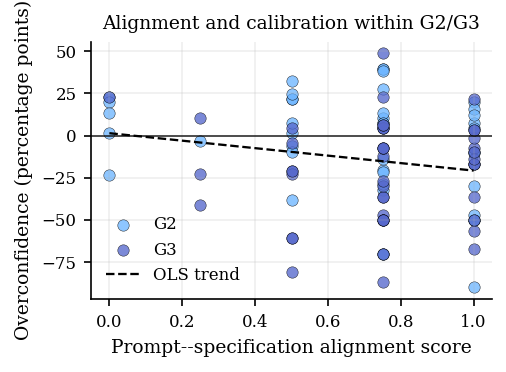

In [16]:

# ============================================================
# Figure 4: Alignment score vs overconfidence in G2/G3
# ============================================================

plot_align = align_df.dropna(subset=['alignment_score', 'overconfidence_pp']).copy()

if len(plot_align) > 0:
    fig, ax = plt.subplots(figsize=(3.45, 2.55))
    for spec in ['G2', 'G3']:
        g = plot_align[plot_align['specification'].astype(str) == spec]
        ax.scatter(
            g['alignment_score'], g['overconfidence_pp'],
            s=30, alpha=.78, edgecolor='black', linewidth=.25,
            color=SPEC_COLORS[spec], label=spec,
        )
    # Overall trend line for visual guidance only.
    if plot_align['alignment_score'].nunique() > 1:
        x = plot_align['alignment_score'].astype(float)
        y = plot_align['overconfidence_pp'].astype(float)
        slope, intercept, r, p, se = stats.linregress(x, y)
        xx = np.linspace(x.min(), x.max(), 100)
        ax.plot(xx, intercept + slope*xx, color='black', linewidth=1.1, linestyle='--', label='OLS trend')
    ax.axhline(0, color='black', linewidth=.8, alpha=.8)
    ax.set_xlabel('Prompt--specification alignment score')
    ax.set_ylabel('Overconfidence (percentage points)')
    ax.set_title('Alignment and calibration within G2/G3')
    ax.grid(axis='both', alpha=.20)
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'rq4_alignment_vs_overconfidence.pdf', bbox_inches='tight')
    fig.savefig(FIG_DIR / 'rq4_alignment_vs_overconfidence.png', bbox_inches='tight')
    plt.show()
else:
    print('No alignment data available for plotting.')



## 11. Sensitivity analysis: prompt effort and prompt type

This section checks whether calibration is related to prompt volume or prompt-category composition. It is not the main RQ4 test, but it helps separate specification effects from interaction behavior.


In [17]:

# ============================================================
# 11. Prompt effort and prompt-type sensitivity analyses
# ============================================================

prompt_predictors = [
    'prompt_count',
    'prompt_total_len',
    'prompt_avg_len',
    'clarification_count',
    'debugging_count',
    'code_generation_count',
    'test_generation_count',
]
# Add prompt-type share columns if available.
prompt_predictors += [c for c in cal2.columns if c.startswith('ptype_') and c.endswith('_share')]

prompt_results = []
for pred in prompt_predictors:
    if pred not in cal2.columns:
        continue
    tmp = cal2.dropna(subset=[pred, 'overconfidence_pp', 'phase', 'specification', 'Task', 'python_skill', 'llm_familiarity']).copy()
    if len(tmp) < 10 or tmp[pred].nunique() <= 1:
        continue
    sd = tmp[pred].std(ddof=1)
    tmp[pred + '_z'] = (tmp[pred] - tmp[pred].mean()) / sd if sd and sd > 0 else tmp[pred]
    f = f'overconfidence_pp ~ {pred}_z + C(specification) + C(phase) + C(Task) + python_skill + llm_familiarity'
    try:
        fit = smf.ols(f, data=tmp).fit(cov_type='cluster', cov_kwds={'groups': tmp['id']})
        term = pred + '_z'
        prompt_results.append({
            'predictor': pred,
            'n': len(tmp),
            'estimate_per_1sd': fit.params.get(term, np.nan),
            'std_error': fit.bse.get(term, np.nan),
            'ci_low': fit.conf_int().loc[term, 0] if term in fit.params.index else np.nan,
            'ci_high': fit.conf_int().loc[term, 1] if term in fit.params.index else np.nan,
            'p_value': fit.pvalues.get(term, np.nan),
        })
    except Exception as e:
        prompt_results.append({'predictor': pred, 'n': len(tmp), 'estimate_per_1sd': np.nan, 'std_error': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'p_value': np.nan})

prompt_results = pd.DataFrame(prompt_results)
if len(prompt_results):
    prompt_results['p_adj_fdr'] = multipletests(prompt_results['p_value'].fillna(1), method='fdr_bh')[1]
    prompt_results.to_csv(TAB_DIR / 'rq4_prompt_sensitivity_models.csv', index=False)
prompt_results.sort_values('p_value').head(15).round(4)


,predictor,n,estimate_per_1sd,std_error,ci_low,ci_high,p_value,p_adj_fdr
3,clarification_count,125,-5.3471,2.5521,-10.3491,-0.3451,0.0362,1.0
0,prompt_count,125,-4.0692,2.4115,-8.7956,0.6572,0.0915,1.0
2,prompt_avg_len,125,3.4512,2.9732,-2.3761,9.2785,0.2457,1.0
5,code_generation_count,125,-3.5706,3.8704,-11.1565,4.0153,0.3563,1.0
1,prompt_total_len,125,-1.3798,2.5758,-6.4283,3.6687,0.5922,1.0
4,debugging_count,125,0.5799,1.9392,-3.2209,4.3807,0.7649,1.0
6,test_generation_count,125,-0.4457,1.9498,-4.2672,3.3757,0.8192,1.0
7,ptype_category_clarification_reason_developer_...,125,NaN,NaN,NaN,NaN,NaN,1.0
8,ptype_category_clarification_reason_developer_...,125,NaN,NaN,NaN,NaN,NaN,1.0
9,ptype_category_clarification_reason_developer_...,125,NaN,NaN,NaN,NaN,NaN,1.0


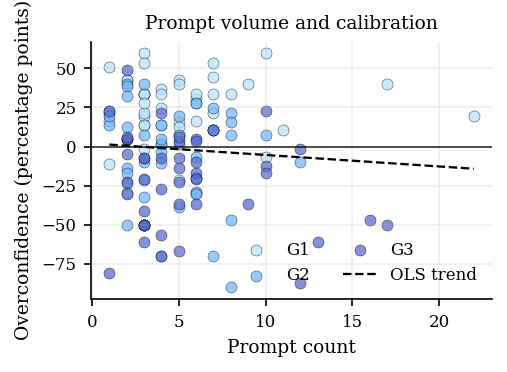

In [18]:

# ============================================================
# Figure 5: Prompt count vs overconfidence
# ============================================================

plot_prompt = cal2.dropna(subset=['prompt_count', 'overconfidence_pp']).copy()
if len(plot_prompt) > 0:
    fig, ax = plt.subplots(figsize=(3.45, 2.55))
    for spec in SPEC_ORDER:
        g = plot_prompt[plot_prompt['specification'].astype(str) == spec]
        ax.scatter(
            g['prompt_count'], g['overconfidence_pp'],
            s=28, alpha=.72, edgecolor='black', linewidth=.25,
            color=SPEC_COLORS[spec], label=spec,
        )
    if plot_prompt['prompt_count'].nunique() > 1:
        x = plot_prompt['prompt_count'].astype(float)
        y = plot_prompt['overconfidence_pp'].astype(float)
        slope, intercept, r, p, se = stats.linregress(x, y)
        xx = np.linspace(x.min(), x.max(), 100)
        ax.plot(xx, intercept + slope*xx, color='black', linewidth=1.1, linestyle='--', label='OLS trend')
    ax.axhline(0, color='black', linewidth=.8, alpha=.8)
    ax.set_xlabel('Prompt count')
    ax.set_ylabel('Overconfidence (percentage points)')
    ax.set_title('Prompt volume and calibration')
    ax.grid(axis='both', alpha=.20)
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'rq4_prompt_count_vs_overconfidence.pdf', bbox_inches='tight')
    fig.savefig(FIG_DIR / 'rq4_prompt_count_vs_overconfidence.png', bbox_inches='tight')
    plt.show()
else:
    print('No prompt summary data available for plotting.')



## 12. Optional robustness: binary overconfidence model

Because overconfidence can also be represented as whether the participant overestimated their performance category, this model uses a binary outcome: overconfident vs. not overconfident.


In [19]:

# ============================================================
# 12. Binary overconfidence robustness model
# ============================================================

bin_df = cal2.dropna(subset=['overconfident_bin', 'specification', 'phase', 'Task', 'python_skill', 'llm_familiarity']).copy()
bin_df['specification'] = pd.Categorical(bin_df['specification'], categories=SPEC_ORDER, ordered=False)
bin_df['phase'] = pd.Categorical(bin_df['phase'], categories=PHASE_ORDER, ordered=False)

bin_formula = 'overconfident_bin ~ C(specification, Treatment(reference="G1")) * C(phase, Treatment(reference="Phase 1")) + C(Task) + python_skill + llm_familiarity'
try:
    bin_fit = smf.glm(bin_formula, data=bin_df, family=sm.families.Binomial()).fit(cov_type='cluster', cov_kwds={'groups': bin_df['id']})
    print(bin_fit.summary())
    bin_coef = pd.DataFrame({
        'term': bin_fit.params.index,
        'log_odds': bin_fit.params.values,
        'odds_ratio': np.exp(bin_fit.params.values),
        'std_error': bin_fit.bse.values,
        'p_value': bin_fit.pvalues.values,
    })
    ci = bin_fit.conf_int()
    bin_coef['or_ci_low'] = np.exp(ci.iloc[:,0].values)
    bin_coef['or_ci_high'] = np.exp(ci.iloc[:,1].values)
    mask = ~bin_coef['term'].str.contains('Intercept', regex=True)
    bin_coef.loc[mask, 'p_adj_fdr'] = multipletests(bin_coef.loc[mask, 'p_value'], method='fdr_bh')[1]
    bin_coef.to_csv(TAB_DIR / 'rq4_binary_overconfidence_model.csv', index=False)
    display(bin_coef.round(4))
except Exception as e:
    print('Binary GLM failed:', repr(e))


                 Generalized Linear Model Regression Results                  
Dep. Variable:      overconfident_bin   No. Observations:                  126
Model:                            GLM   Df Residuals:                      117
Model Family:                Binomial   Df Model:                            8
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -54.588
Date:                Tue, 30 Jun 2026   Deviance:                       109.18
Time:                        20:41:36   Pearson chi2:                     113.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3901
Covariance Type:              cluster                                         
                                                                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------

,term,log_odds,odds_ratio,std_error,p_value,or_ci_low,or_ci_high,p_adj_fdr
0,Intercept,-0.5127,0.5989,1.3673,0.7077,0.0411,8.7341,NaN
1,"C(specification, Treatment(reference=""G1""))[T.G2]",-1.7446,0.1747,0.8644,0.0436,0.0321,0.9509,0.1162
2,"C(specification, Treatment(reference=""G1""))[T.G3]",-3.9611,0.0190,1.1028,0.0003,0.0022,0.1654,0.0026
3,"C(phase, Treatment(reference=""Phase 1""))[T.Pha...",0.3863,1.4715,0.8963,0.6665,0.2540,8.5246,0.8088
4,C(Task)[T.B],-0.7859,0.4557,0.5842,0.1785,0.1450,1.4320,0.3570
5,"C(specification, Treatment(reference=""G1""))[T....",-1.2844,0.2768,1.1454,0.2621,0.0293,2.6130,0.4194
6,"C(specification, Treatment(reference=""G1""))[T....",-0.3366,0.7142,0.8977,0.7077,0.1229,4.1494,0.8088
7,python_skill,-0.0381,0.9626,0.2637,0.8851,0.5741,1.6141,0.8851
8,llm_familiarity,0.7378,2.0913,0.2750,0.0073,1.2198,3.5853,0.0292



## 13. Ready-to-use result snippets

The following cells print compact values that can be copied into the RQ4 results subsection after inspecting the statistical outputs.


In [20]:

# ============================================================
# 13. Result helper summaries
# ============================================================

print('Primary model used:', model_used)
print('\nDescriptive overconfidence means by phase and condition:')
for _, r in desc.iterrows():
    print(f"{r['phase']} {r['specification']}: n={int(r['n'])}, "
          f"pred={r['predicted_pct_mean']:.1f}%, actual={r['actual_pct_mean']:.1f}%, "
          f"overconfidence={r['overconfidence_pp_mean']:.1f} pp "
          f"[{r['overconfidence_pp_ci_low']:.1f}, {r['overconfidence_pp_ci_high']:.1f}], "
          f"abs error={r['abs_error_pp_mean']:.1f} pp")

print('\nPairwise contrasts, FDR-adjusted:')
display(contrasts.round(3))

if len(align_results):
    print('\nAlignment sensitivity models, FDR-adjusted:')
    display(align_results.round(3))


Primary model used: MixedLM random-intercept model

Descriptive overconfidence means by phase and condition:
Phase 1 G1: n=24, pred=57.5%, actual=34.7%, overconfidence=22.8 pp [13.2, 32.3], abs error=29.4 pp
Phase 1 G2: n=22, pred=45.5%, actual=39.8%, overconfidence=5.6 pp [-3.2, 14.5], abs error=16.9 pp
Phase 1 G3: n=24, pred=43.3%, actual=65.5%, overconfidence=-22.2 pp [-37.2, -7.2], abs error=31.6 pp
Phase 2 G1: n=24, pred=62.5%, actual=39.8%, overconfidence=22.7 pp [13.5, 31.9], abs error=26.1 pp
Phase 2 G2: n=23, pred=56.1%, actual=73.5%, overconfidence=-17.4 pp [-33.0, -1.9], abs error=32.0 pp
Phase 2 G3: n=23, pred=56.1%, actual=74.3%, overconfidence=-18.2 pp [-31.2, -5.2], abs error=28.4 pp

Pairwise contrasts, FDR-adjusted:


,family,phase,contrast,estimate_diff_pp,test,statistic,p_value,hedges_g,p_adj_fdr
0,condition_within_phase,Phase 1,G2 - G1,-17.130,Welch t-test,-2.733,0.009,-0.788,0.014
1,condition_within_phase,Phase 1,G3 - G1,-44.975,Welch t-test,-5.236,0.000,-1.487,0.000
2,condition_within_phase,Phase 1,G3 - G2,-27.844,Welch t-test,-3.315,0.002,-0.940,0.005
3,condition_within_phase,Phase 2,G2 - G1,-40.158,Welch t-test,-4.600,0.000,-1.333,0.000
4,condition_within_phase,Phase 2,G3 - G1,-40.949,Welch t-test,-5.321,0.000,-1.537,0.000
5,condition_within_phase,Phase 2,G3 - G2,-0.791,Welch t-test,-0.081,0.936,-0.023,0.992
6,phase_within_condition,Phase 2 - Phase 1,G1: Phase 2 - Phase 1,-0.051,paired t-test,-0.010,0.992,-0.002,0.992
7,phase_within_condition,Phase 2 - Phase 1,G2: Phase 2 - Phase 1,-25.714,paired t-test,-3.403,0.003,-0.743,0.005
8,phase_within_condition,Phase 2 - Phase 1,G3: Phase 2 - Phase 1,1.423,paired t-test,0.324,0.749,0.068,0.963



Alignment sensitivity models, FDR-adjusted:


,predictor,n,estimate,std_error,ci_low,ci_high,p_value,model,p_adj_fdr
0,alignment_score,86,-7.770,3.510,-14.650,-0.890,0.027,"OLS with participant-clustered SEs, adjusted f...",0.094
1,omission_rate,86,7.770,3.510,0.890,14.650,0.027,"OLS with participant-clustered SEs, adjusted f...",0.094
2,explicitly_referred_to_specification,86,-5.229,3.423,-11.938,1.480,0.127,"OLS with participant-clustered SEs, adjusted f...",0.222
3,carried_constraints_from_spec,86,-3.801,2.757,-9.205,1.603,0.168,"OLS with participant-clustered SEs, adjusted f...",0.235
4,carried_edge_cases_from_spec,86,-4.179,2.734,-9.537,1.179,0.126,"OLS with participant-clustered SEs, adjusted f...",0.222
5,asked_to_preserve_invariants,86,-2.688,3.245,-9.048,3.672,0.407,"OLS with participant-clustered SEs, adjusted f...",0.475
6,asked_to_update_or_generate_tests_based_on_spec,86,-2.118,3.368,-8.720,4.484,0.530,"OLS with participant-clustered SEs, adjusted f...",0.530



## 14. Output files

The notebook writes all generated tables and figures to:

- `rq4_outputs_q3q5/tables/`
- `rq4_outputs_q3q5/figures/`

Recommended figures for the ICSE paper:

1. `rq4_overconfidence_by_condition_phase.pdf` — main RQ4 figure;
2. `rq4_phase_change_overconfidence.pdf` — useful if the phase interaction matters;
3. `rq4_alignment_vs_overconfidence.pdf` — sensitivity analysis figure if alignment is discussed.
